Thomas Sears

10-4-26

Lab 6 - Rotation

In [8]:
import numpy as np
import matplotlib.pyplot as plt

Part A — The Physical Pendulum

Description: 

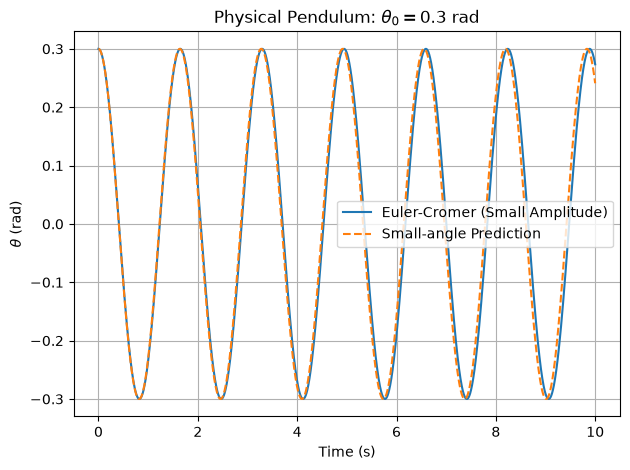

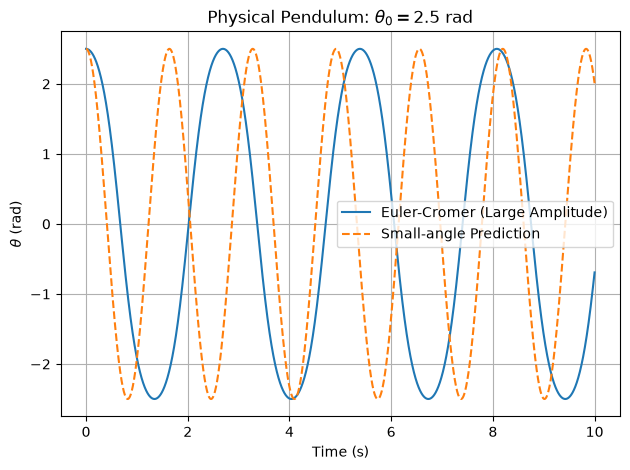

Small-angle angular frequency Ω = 3.8341 rad/s
Small-angle period T = 1.6388 s


In [9]:
# Parameters
L = 1.0         
m = 1.0         
g = 9.8         
d = L / 2
I = (1/3) * m * L**2

# Angular frequency
Omega = np.sqrt(m * g * d / I)

# Simulation parameters
dt = 0.001
t_max = 10.0
t = np.arange(0, t_max, dt)

# Euler-Cromer simulation
def simulate_pendulum(theta0):
    theta = np.zeros(len(t))
    omega = np.zeros(len(t))

    # Initial conditions
    theta[0] = theta0
    omega[0] = 0.0

    for i in range(len(t) - 1):

        # Torque
        tau = -m * g * d * np.sin(theta[i])

        # Angular acceleration
        alpha = tau / I

        omega[i + 1] = omega[i] + alpha * dt
        theta[i + 1] = theta[i] + omega[i + 1] * dt

    return theta


# Simulate both amplitudes
theta_small = simulate_pendulum(0.3)
theta_large = simulate_pendulum(2.5)

# Small-angle predictions
theta_small_prediction = 0.3 * np.cos(Omega * t)
theta_large_prediction = 2.5 * np.cos(Omega * t)


# Small Amplitude Plot
plt.plot(t, theta_small, label="Euler-Cromer (Small Amplitude)")
plt.plot(t, theta_small_prediction, "--", label="Small-angle Prediction")
plt.xlabel("Time (s)")
plt.ylabel(r"$\theta$ (rad)")
plt.title(r"Physical Pendulum: $\theta_0 = 0.3$ rad")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Large Amplitude Plot
plt.plot(t, theta_large, label="Euler-Cromer (Large Amplitude)")
plt.plot(t, theta_large_prediction, "--", label="Small-angle Prediction")
plt.xlabel("Time (s)")
plt.ylabel(r"$\theta$ (rad)")
plt.title(r"Physical Pendulum: $\theta_0 = 2.5$ rad")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Small-angle period
T_small = 2 * np.pi / Omega
print(f"Small-angle angular frequency Ω = {Omega:.4f} rad/s")
print(f"Small-angle period T = {T_small:.4f} s")

Discussion: For the larger amplitude pendulum, the real period from the Euler-Cromer method is larger than the small-angle approximation for the same amplitude. This is because like the name suggests, small-angle approximations are only accurate to a certain relatively small amplitude. When sin(theta) is non-negligably different from theta, the small-angle approximation becomes less accurate. Back in Lab 3, we looked at a non-linear SHO with a driving force where the same problems occur when the amplitude gets too high. At higher amplitudes, Hooke's Law breaks down and the system becomes more complicated similar to what happens in this lab.

Part B — The Rolling Race

Description: 